In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Predicting Daily Biogas Production Using Machine Learning

## 1. Research problem
### 1.1. Background

Biogas production from organic waste plays an important role in sustainable energy generation and waste management. The ability to accurately predict daily biogas output enables better planning of energy supply and optimization of the anaerobic digestion process. This project uses a 15-year representing dataset from a biogas plant in India to develop regression models capable of predicting daily biogas production and supporting operational decision-making in similar facilities.

### 1.2 Business Perspective

Can daily biogas production (m³) be predicted from feedstock composition, operational parameters, and environmental conditions with sufficient accuracy to support the operation and planning of a biogas plant?

### 1.3 Data science Perspective
Build regression model that predicts continous value of Raw Biogas Produced (m³) using 25 scalar values. Model will be evaluated base on R² and RMSE where a good values will be considered R^2 > 0.75 and RMSE < 10% for mean biogas production.
Why these values? 0.75 will show a good 

For a biogas plant prediction of 10% error is acceptable because the gas storage buffer absorbs the daily fluctuations. According to the literature gasholders are designed as buffer devices that adjust peaks and fluctuations in biogas production.<sup>[1]</sup> The typical storage production is 10-30% of the daily production for continuously operating systems. A prediction error of 10% falls into this range, which means that the plant can absorb such a deviation without operation disturbance.  

#### 1.4. Hypothesis

A machine learning model can predict daily biogas production from feedstock composition, environmental conditions, and operational parameters with useful accuracy (R² > 0.75).

## 2. Hypothesis - reconsider
Null hypothesis (H₀)

The available input variables (waste composition, operational parameters, and weather conditions) do not provide meaningful predictive information about daily biogas production.

Any prediction model will perform no better than a simple baseline using the average daily production.

Feedstock quantities, biological process parameters, and environmental conditions are not associated with daily biogas production.

Alternative hypothesis (H₁)

Feedstock quantities, biological process parameters, and environmental conditions are associated with daily biogas production. Specifically, higher quantities of organic feedstock and favorable digestion conditions are expected to increase biogas production.

A regression model trained on these variables will significantly outperform a baseline model. 
We expect:

* Models using waste composition, operational parameters, and weather conditions to outperform a baseline model.
* Waste quantity variables to show a positive relationship with biogas production.
* Feature importance analysis to identify waste composition as one of the key drivers of production.

The hypothesis will be considered supported if:

* the final model achieves R² ≥ 0.75;
* RMSE remains below 10% of the mean daily production;
* models including waste-related features perform substantially better than models using weather variables alone.

Summary:
We expect tree-based ensemble models (Random Forest and Gradient Boosting) to outperform a simple linear regression baseline because biogas production is influenced by multiple interacting process and environmental variables.


## 2. Dataset Overview
The dataset contains 25 operational data from a biogas plant, including feedstock quantities, environmental conditions, and process-related variables.

## Feature Categories

| Category | Examples |

|-----------|----------|

| Feedstock | Pig Manure, Kitchen Food Waste, Chicken Litter, Fish Waste |

| Operational | Water Usage, Diesel Consumption, Electricity Usage |

| Environmental | Temperature, Humidity, Rainfall |

| Process Variables | Digester Temperature, C/N Ratio |

| Target | biogas_production |

Explaination of the features

Based on domain knowledge of anaerobic digestion, several variables in the dataset are known to influence biogas production.:

* Feedstock Composition: Kitchen food waste, Pig manure, Chicken litter
* Volatile solids
* Digester temperature
* Hydraulic retention time (HRT)
* C/N ratio

*Technical Background*

**Feedstock Composition**

Biogas is produced through anaerobic digestion of organic materials. Feedstocks such as kitchen food waste, pig manure, chicken litter, and municipal residues provide the organic matter that microorganisms convert into biogas. In general, larger quantities of biodegradable material are expected to increase gas production.

**Volatile Solids (VS)**

Volatile solids represent the biodegradable portion of the feedstock. Since microorganisms consume this organic matter during digestion, higher volatile solids content is generally associated with greater biogas production potential.

**Digester Temperature**

Microbial activity depends strongly on temperature. Digestion is most efficient within specific temperature ranges, while lower temperatures can reduce gas production by slowing microbial processes.

**Hydraulic Retention Time (HRT)**

Hydraulic Retention Time measures how long the feedstock remains inside the digester. Longer retention times allow microorganisms more time to break down organic material and produce biogas.

**Carbon-to-Nitrogen Ratio (C/N Ratio)**

The C/N ratio describes the balance between carbon and nitrogen in the feedstock. An appropriate balance supports microbial growth and efficient digestion, while an imbalance may reduce biogas yield.

## Dataset Structure


In [4]:
biogas_data = pd.read_csv('biogas_dataset.csv')
biogas_data.shape
biogas_data.head()
biogas_data.info()
biogas_data.dtypes


<class 'pandas.DataFrame'>
RangeIndex: 15298 entries, 0 to 15297
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     15298 non-null  int64  
 1   Month                    15298 non-null  int64  
 2   Day                      15298 non-null  int64  
 3   Pig Manure (kg)          15298 non-null  float64
 4   Kitchen Food Waste (kg)  15298 non-null  float64
 5   Chicken Litter (kg)      15298 non-null  float64
 6   Cassava (kg)             15298 non-null  float64
 7   Bagasse Feed (kg)        15298 non-null  float64
 8   Energy Grass (kg)        15298 non-null  float64
 9   Banana Shafts (kg)       15298 non-null  float64
 10  Alcohol Waste (kg)       15298 non-null  float64
 11  Municipal Residue (kg)   15298 non-null  float64
 12  Fish Waste (kg)          15298 non-null  float64
 13  Water (L)                15298 non-null  float64
 14  Diesel (L)               15298 no

Year                         int64
Month                        int64
Day                          int64
Pig Manure (kg)            float64
Kitchen Food Waste (kg)    float64
Chicken Litter (kg)        float64
Cassava (kg)               float64
Bagasse Feed (kg)          float64
Energy Grass (kg)          float64
Banana Shafts (kg)         float64
Alcohol Waste (kg)         float64
Municipal Residue (kg)     float64
Fish Waste (kg)            float64
Water (L)                  float64
Diesel (L)                 float64
Electricity Use (kWh)      float64
Temperature (C)            float64
Humidity (%)               float64
Rainfall (mm)              float64
C/N Ratio                  float64
Digester Temp (C)          float64
biogas_production          float64
dtype: object

### Initial Observations

Dataset contains 15,298 observations. All variables are numerical (`int64` or `float64`). No categorical variables are present. The target variable is `biogas_production`.

# 4. Data Quality Assessment

In [13]:
print(biogas_data.isnull().sum())
print(f"Duplicates: {biogas_data.duplicated().sum()}")

Year                       0
Month                      0
Day                        0
Pig Manure (kg)            0
Kitchen Food Waste (kg)    0
Chicken Litter (kg)        0
Cassava (kg)               0
Bagasse Feed (kg)          0
Energy Grass (kg)          0
Banana Shafts (kg)         0
Alcohol Waste (kg)         0
Municipal Residue (kg)     0
Fish Waste (kg)            0
Water (L)                  0
Diesel (L)                 0
Electricity Use (kWh)      0
Temperature (C)            0
Humidity (%)               0
Rainfall (mm)              0
C/N Ratio                  0
Digester Temp (C)          0
biogas_production          0
dtype: int64
Duplicates: 0


In [15]:
biogas_data.dtypes

Year                         int64
Month                        int64
Day                          int64
Pig Manure (kg)            float64
Kitchen Food Waste (kg)    float64
Chicken Litter (kg)        float64
Cassava (kg)               float64
Bagasse Feed (kg)          float64
Energy Grass (kg)          float64
Banana Shafts (kg)         float64
Alcohol Waste (kg)         float64
Municipal Residue (kg)     float64
Fish Waste (kg)            float64
Water (L)                  float64
Diesel (L)                 float64
Electricity Use (kWh)      float64
Temperature (C)            float64
Humidity (%)               float64
Rainfall (mm)              float64
C/N Ratio                  float64
Digester Temp (C)          float64
biogas_production          float64
dtype: object

### Findings
No missing values or duplicate records were identified in the dataset. All features are stored as numerical values and are suitable for regression analysis.
No categorical features are present, therefore no encoding techniques are required.

# 5. Exploratory Data Analysis (EDA)

## 5.1 Summary Statistics


In [57]:
biogas_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,15298.0,2016.999477,4.320433,2010.000000,2013.000000,2017.000000,2021.000000,2024.000000
Month,15298.0,6.521571,3.448833,1.000000,4.000000,7.000000,10.000000,12.000000
Day,15298.0,15.723101,8.799470,1.000000,8.000000,16.000000,23.000000,31.000000
Pig Manure (kg),15298.0,25.097493,9.869836,0.103366,18.270828,25.007929,31.805712,60.711466
Kitchen Food Waste (kg),15298.0,17.945933,6.975865,0.002521,13.181458,17.880665,22.611847,47.323544
Chicken Litter (kg),15298.0,12.014503,4.912169,0.001158,8.633978,12.002030,15.279068,31.294118
Cassava (kg),15298.0,20.034405,7.938863,0.001361,14.561289,20.081747,25.349684,49.149914
Bagasse Feed (kg),15298.0,15.087888,5.969113,0.007269,11.026886,15.124088,19.187529,38.563105
Energy Grass (kg),15298.0,10.037762,3.941196,0.011412,7.368683,10.037847,12.695036,25.423541
Banana Shafts (kg),15298.0,8.012272,3.006955,0.004688,5.968436,8.004483,10.047839,21.421714


In [58]:
# biogas_data['biogas_production'].describe()

In [17]:
biogas_data['biogas_production'].skew()

np.float64(0.18553199353932806)

Dataset Summary Statistics:

The dataset contains 15,298 daily records with 22 numerical features. All features have complete data (no missing values). The target variable, biogas production, ranges from 41.9 to 121.7 m³ with a mean of 79.2 m³ and a median of 78.8 m³, indicating a relatively symmetric distribution with moderate variability (σ = 11.3 m³).

Feedstock quantities show wide variation: Pig Manure averages 130.8 kg/day (range: 0-320 kg), Kitchen Food Waste averages 139.7 kg/day (range: 0-293 kg), and Chicken Litter averages 81.8 kg/day (range: 0-230 kg). Environmental conditions are relatively stable, with Temperature averaging 28.9°C (range: 20.4-39.6°C) and Humidity at 61.0% (range: 31.3-87.7%).

The substantial range in feedstock quantities suggests significant operational variability, which likely contributes to the observed variation in biogas production.

Daily biogas production ranged from 41.9 m³ to 121.7 m³, with a mean of 79.2 m³ and a median of 78.8 m³. The small difference between the mean and median, together with a skewness value of 0.19, indicates an approximately symmetric distribution. The interquartile range (71.3–86.7 m³) shows that most observations are concentrated around the central tendency, suggesting relatively stable production levels with no obvious extreme anomalies.

As we can see features have different scales, from which we can make a conclusion that we need scaling for linear models.

## 5.3 Distribution and outliers investigation


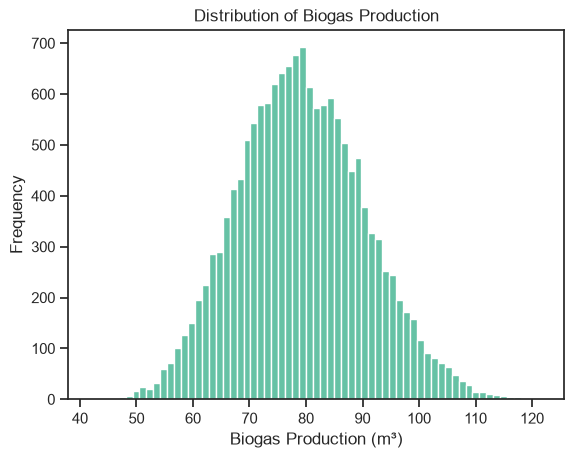

In [50]:
plt.hist(biogas_data["biogas_production"], bins="fd")
plt.title("Distribution of Biogas Production")
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Frequency")
plt.show()

The distribution of daily biogas production appears  bell-shaped with a single peak, the histogram contains a single dominant peak, no strong skewness (skewness is approximately 0.19, indicating only slight positive skewness.): all these findings suggest a relatively stable production process without obvious subgroups or extreme asymmetry in the target variable.


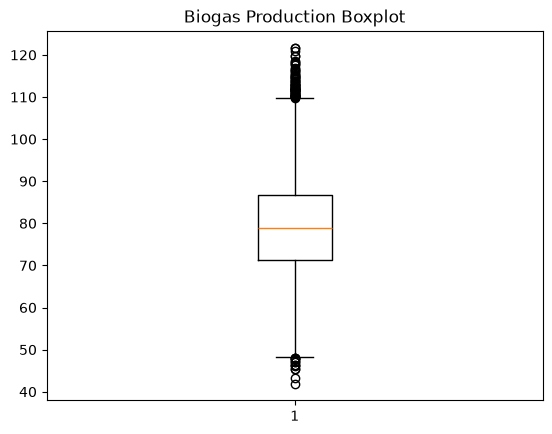

In [24]:
plt.boxplot(biogas_data["biogas_production"])
plt.title("Biogas Production Boxplot")
plt.show()

The boxplot indicates the presence of several observations outside the interquartile range boundaries. These values may represent unusually high or low production days. Since they may correspond to genuine operational conditions rather than data errors, no observations were removed at this stage.

In [27]:
Q1 = biogas_data["biogas_production"].quantile(0.25)
Q3 = biogas_data["biogas_production"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = biogas_data[
    (biogas_data["biogas_production"] < lower) |
    (biogas_data["biogas_production"] > upper)
]

print(len(outliers))

83


We find out that there is 83 outliers out of 15,298 rows. This can be interpritated as most production days behave similarly, while a small number of days show unusually low or high production.

## 5.4 Relationship Between Key Features and Biogas Production

### Kitchen Food Waste vs Biogas Production

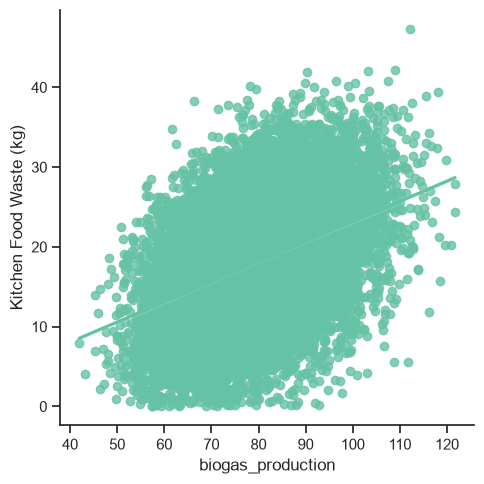

In [32]:
sns.set(style='ticks', palette='Set2')
sns.lmplot(x="biogas_production", y="Kitchen Food Waste (kg)", data=biogas_data)


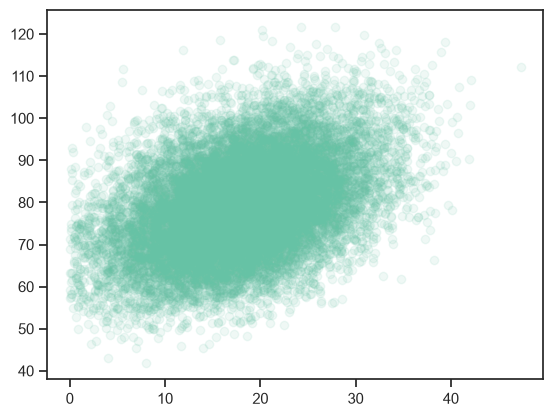

In [33]:
plt.scatter(
    biogas_data["Kitchen Food Waste (kg)"],
    biogas_data["biogas_production"],
    alpha=0.1
)

In [34]:
biogas_data[

    ["Kitchen Food Waste (kg)", "biogas_production"]

].corr()

,Kitchen Food Waste (kg),biogas_production
Kitchen Food Waste (kg),1.000000,0.407208
biogas_production,0.407208,1.000000


Kitchen Food Waste alone does not show a strong relationship with biogas production.

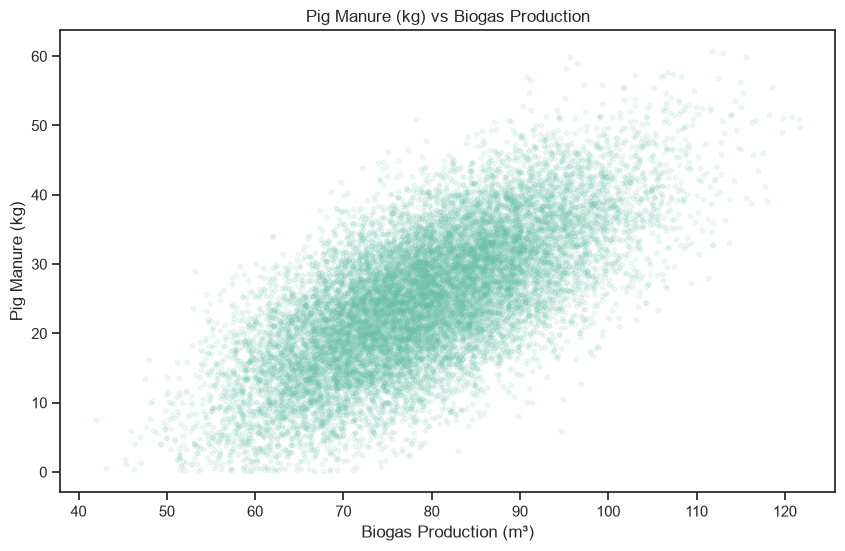

In [56]:
#sns.set(style='ticks', palette='Set2')
#sns.lmplot(x="biogas_production", y="Pig Manure (kg)", data=biogas_data)

plt.figure(figsize=(10, 6))
plt.scatter(biogas_data["biogas_production"], 
            biogas_data["Pig Manure (kg)"], 
            alpha=0.1, s=10)
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Pig Manure (kg)")
plt.title("Pig Manure (kg) vs Biogas Production")
plt.show()

In [37]:
biogas_data[

    ["Pig Manure (kg)", "biogas_production"]

].corr()

,Pig Manure (kg),biogas_production
Pig Manure (kg),1.000000,0.695072
biogas_production,0.695072,1.000000


The scatter plot of Pig Manure versus biogas production shows a clear positive trend. The Pearson correlation coefficient of 0.695 indicates a strong positive linear relationship, suggesting that pig manure quantity may be an important predictor of biogas production.

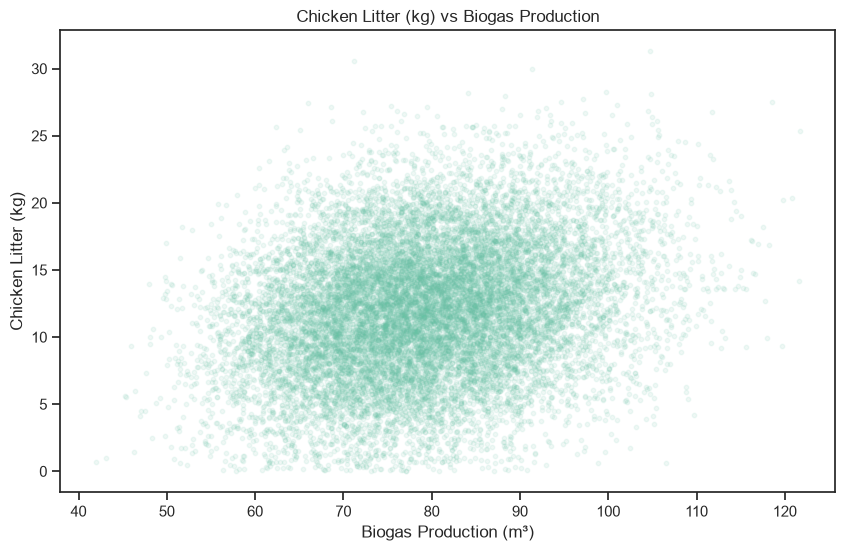

In [54]:
#sns.set(style='ticks', palette='Set2')
#sns.lmplot(x="biogas_production", y="Chicken Litter (kg)", data=biogas_data)
plt.figure(figsize=(10, 6))
plt.scatter(biogas_data["biogas_production"], 
            biogas_data["Chicken Litter (kg)"], 
            alpha=0.1, s=10)
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Chicken Litter (kg)")
plt.title("Chicken Litter (kg) vs Biogas Production")
plt.show()

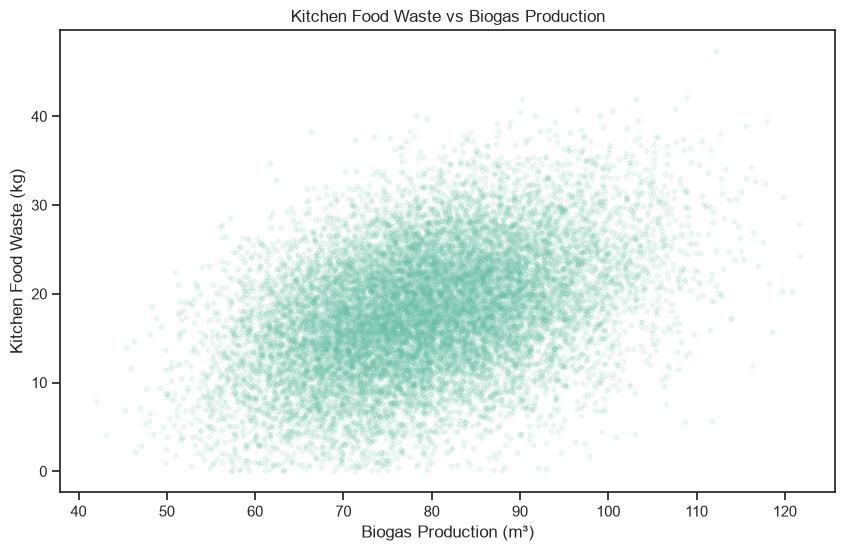

In [53]:
plt.figure(figsize=(10, 6))
plt.scatter(biogas_data["biogas_production"], 
            biogas_data["Kitchen Food Waste (kg)"], 
            alpha=0.1, s=10)
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Kitchen Food Waste (kg)")
plt.title("Kitchen Food Waste vs Biogas Production")
plt.show()


In [39]:
biogas_data[

    ["Pig Manure (kg)", "biogas_production"]

].corr()

,Chicken Litter (kg),biogas_production
Chicken Litter (kg),1.000000,0.249052
biogas_production,0.249052,1.000000


In [42]:
corr = (biogas_data.corr(numeric_only=True)["biogas_production"].sort_values(ascending=False))
print(corr)

biogas_production          1.000000
Pig Manure (kg)            0.695072
Kitchen Food Waste (kg)    0.407208
Cassava (kg)               0.342333
Municipal Residue (kg)     0.272619
Chicken Litter (kg)        0.249052
Bagasse Feed (kg)          0.216974
Water (L)                  0.138231
Temperature (C)            0.122816
Energy Grass (kg)          0.092863
Fish Waste (kg)            0.073418
Alcohol Waste (kg)         0.047514
Banana Shafts (kg)         0.045427
Electricity Use (kWh)      0.016916
Diesel (L)                 0.012036
Month                      0.007012
Rainfall (mm)              0.003375
C/N Ratio                 -0.002593
Digester Temp (C)         -0.004840
Year                      -0.007930
Humidity (%)              -0.009982
Day                       -0.010809
Name: biogas_production, dtype: float64


Correlation analysis revealed that Pig Manure exhibited the strongest positive relationship with biogas production (r = 0.695). Kitchen Food Waste (r = 0.407) and Cassava (r = 0.342) showed moderate positive associations. Several variables, including Humidity, Digester Temperature, and C/N Ratio, displayed correlations close to zero, indicating little evidence of a linear relationship with biogas production. However, low correlation values do not necessarily imply that a variable is unimportant, as nonlinear relationships may still exist.

This way we can see that Pig Manure looks like the dominant predictor in this dataset, much more than Chicken Litter or Kitchen Food Waste. That’s a meaningful finding before even have trained a model.

In [60]:
biogas_data["Month"].value_counts().sort_index()

Month
1     1300
2     1184
3     1298
4     1257
5     1297
6     1256
7     1300
8     1299
9     1256
10    1298
11    1256
12    1297
Name: count, dtype: int64

In [61]:
biogas_data["Year"].value_counts().sort_index()
biogas_data["Day"].value_counts().sort_index()

Day
1     504
2     507
3     496
4     511
5     496
6     504
7     503
8     503
9     501
10    508
11    497
12    506
13    500
14    503
15    501
16    507
17    501
18    503
19    502
20    502
21    501
22    504
23    504
24    503
25    502
26    502
27    502
28    505
29    471
30    460
31    289
Name: count, dtype: int64

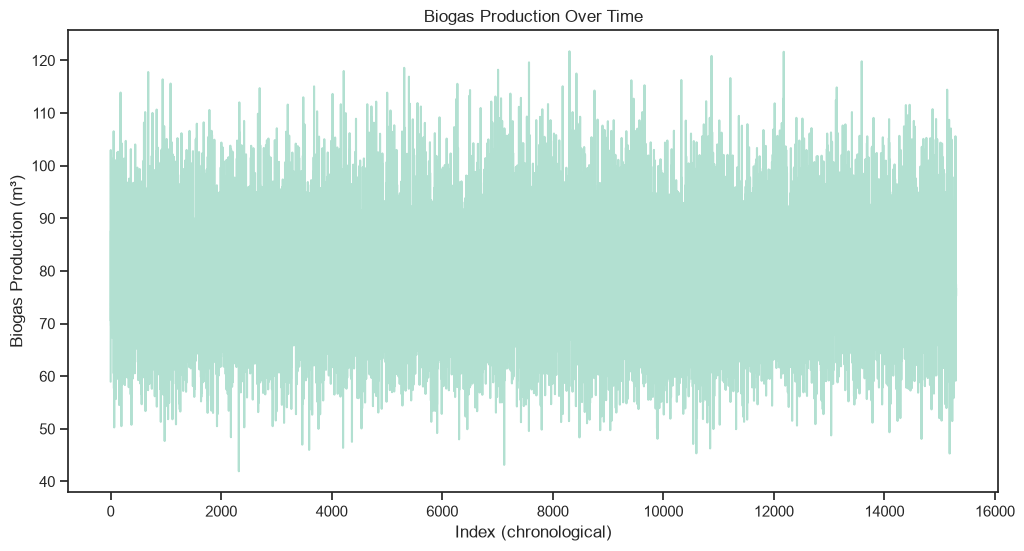

In [62]:
# Plot biogas production over time
plt.figure(figsize=(12, 6))
plt.plot(biogas_data.index, biogas_data['biogas_production'], alpha=0.5)
plt.xlabel('Index (chronological)')
plt.ylabel('Biogas Production (m³)')
plt.title('Biogas Production Over Time')
plt.show()

In [63]:
years = biogas_data.groupby('Year')['biogas_production'].mean()
print("Average biogas by year:")
print(years)

Average biogas by year:
Year
2010    79.559753
2011    79.429558
2012    79.376628
2013    79.184270
2014    79.442158
2015    79.062364
2016    79.191778
2017    79.278391
2018    78.939261
2019    78.859438
2020    78.902621
2021    79.273738
2022    78.929998
2023    79.289642
2024    79.446653
Name: biogas_production, dtype: float64


# 6. Preprocessing

## Planned Steps
- Target Variable Separation
- Train/Test Split
- Feature Scaling (if required)

Since the dataset contains no missing values, duplicates, or categorical variables, preprocessing requirements are minimal.

Also the analysis has showen near-zero correlation between temporal features (Year, Month, Day) and biogas production (|r| < 0.011), we used random 80/20 train-test split. The temporal stability of the data (yearly means ranging only 78.9-79.6 m³) suggests that chronological ordering does not significantly affect the prediction task.

In [64]:
biogas_data_attributes = biogas_data.drop(columns = ["biogas_production"])
biogas_data_target = biogas_data.biogas_production

In [67]:
biogas_data_attributes_train, biogas_data_attributes_test, biogas_data_target_train, biogas_data_target_test = train_test_split(
    biogas_data_attributes, biogas_data_target, test_size=0.2, random_state=42
)
biogas_data_attributes_train, biogas_data_attributes_val, biogas_data_target_train, biogas_data_target_val = train_test_split(biogas_data_attributes_train, biogas_data_target_train, test_size=0.2, random_state=42)

biogas_data_attributes_train.shape, biogas_data_attributes_val.shape, biogas_data_attributes_test.shape, biogas_data_target_train.shape, biogas_data_target_val.shape, biogas_data_target_test.shape


((9790, 21), (2448, 21), (3060, 21), (9790,), (2448,), (3060,))

Lets verify that splits are representative:

In [68]:
print("Training set:")
print(f"  Biogas mean: {biogas_data_target_train.mean():.2f}")
print(f"  Biogas std:  {biogas_data_target_train.std():.2f}")
print()

print("Validation set:")
print(f"  Biogas mean: {biogas_data_target_val.mean():.2f}")
print(f"  Biogas std:  {biogas_data_target_val.std():.2f}")
print()

print("Test set:")
print(f"  Biogas mean: {biogas_data_target_test.mean():.2f}")
print(f"  Biogas std:  {biogas_data_target_test.std():.2f}")

Training set:
  Biogas mean: 79.23
  Biogas std:  11.25

Validation set:
  Biogas mean: 79.13
  Biogas std:  11.44

Test set:
  Biogas mean: 79.20
  Biogas std:  11.13


All three means are very close to ~79.2, confirming the random split worked good enough.

****Scaling
The features can have vastly different scales. That's because:

Pig Manure (kg): ranges from 0 to 5000
C/N Ratio: ranges from 0 to 30
Temperature (C): ranges from 10 to 40

In linear regression, the coefficients (weights) are learned by minimizing the cost function. Features on different scales (e.g., 0-5000 kg vs 10-40°C) make gradient descent slow and unstable because the algorithm treats all units equally. Feature importance becomes misleading. 

In [71]:
scaler = StandardScaler()
biogas_data_attributes_train_scaled = scaler.fit_transform(biogas_data_attributes_train)
biogas_data_attributes_val_scaled = scaler.transform(biogas_data_attributes_val)
biogas_data_attributes_test_scaled = scaler.transform(biogas_data_attributes_test)

In [52]:
#linear_regression_baseline = LinearRegression()
#linear_regression_baseline.fit(biogas_data_attributes_train_scaled, biogas_data_target_train)

In [72]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (50)': RandomForestRegressor(n_estimators=50, random_state=42),
    'Random Forest (100)': RandomForestRegressor(n_estimators=100, random_state=42),
    'Random Forest (200)': RandomForestRegressor(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(biogas_data_attributes_train_scaled, biogas_data_target_train)
    val_score = model.score(biogas_data_attributes_val_scaled, biogas_data_target_val)
    results[name] = val_score
    print(f"{name:20} Val R²: {val_score:.4f}")

# Pick best
best_name = max(results, key=results.get)
print(f"\n Best model: {best_name} with R² = {results[best_name]:.4f}")

Linear Regression    Val R²: 0.9944
Random Forest (50)   Val R²: 0.9040
Random Forest (100)  Val R²: 0.9053
Random Forest (200)  Val R²: 0.9066

 Best model: Linear Regression with R² = 0.9944


In [73]:
X_train_single = biogas_data_attributes_train[['Pig Manure (kg)']]
X_val_single = biogas_data_attributes_val[['Pig Manure (kg)']]
X_test_single = biogas_data_attributes_test[['Pig Manure (kg)']]

# Scale
scaler_single = StandardScaler()
X_train_single_scaled = scaler_single.fit_transform(X_train_single)
X_val_single_scaled = scaler_single.transform(X_val_single)
X_test_single_scaled = scaler_single.transform(X_test_single)

# Train models
lr_single = LinearRegression()
lr_single.fit(X_train_single_scaled, biogas_data_target_train)
rf_single = RandomForestRegressor(n_estimators=100, random_state=42)
rf_single.fit(X_train_single_scaled, biogas_data_target_train)

print("With ONLY Pig Manure:")
print(f"  Linear Regression Val R²: {lr_single.score(X_val_single_scaled, biogas_data_target_val):.4f}")
print(f"  Random Forest Val R²: {rf_single.score(X_val_single_scaled, biogas_data_target_val):.4f}")

With ONLY Pig Manure:
  Linear Regression Val R²: 0.4846
  Random Forest Val R²: 0.2628


In [74]:
# Check feature importance with all features (from earlier)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(biogas_data_attributes_train_scaled, biogas_data_target_train)

importance_df = pd.DataFrame({
    'feature': biogas_data_attributes_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (All Features):")
print(importance_df)

Feature Importance (All Features):
                    feature  importance
3           Pig Manure (kg)    0.489981
4   Kitchen Food Waste (kg)    0.159505
6              Cassava (kg)    0.114213
11   Municipal Residue (kg)    0.062760
5       Chicken Litter (kg)    0.056927
7         Bagasse Feed (kg)    0.036436
16          Temperature (C)    0.011301
13                Water (L)    0.011254
8         Energy Grass (kg)    0.007772
12          Fish Waste (kg)    0.006468
9        Banana Shafts (kg)    0.005306
10       Alcohol Waste (kg)    0.004577
15    Electricity Use (kWh)    0.004535
17             Humidity (%)    0.004166
18            Rainfall (mm)    0.004085
19                C/N Ratio    0.004030
14               Diesel (L)    0.004008
20        Digester Temp (C)    0.003964
2                       Day    0.003289
0                      Year    0.002809
1                     Month    0.002614


In [75]:
linear_model = LinearRegression()
linear_model.fit(
    biogas_data_attributes_train_scaled,
    biogas_data_target_train
)
pd.DataFrame({
    "Feature": biogas_data_attributes_train.columns,
    "Coefficient": linear_model.coef_
}).sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
3,Pig Manure (kg),7.789058
4,Kitchen Food Waste (kg),4.553580
6,Cassava (kg),3.888908
11,Municipal Residue (kg),2.889917
5,Chicken Litter (kg),2.864127
7,Bagasse Feed (kg),2.455603
16,Temperature (C),1.478446
13,Water (L),1.407112
8,Energy Grass (kg),1.088650
12,Fish Waste (kg),0.844259


In [ ]:
# Use the best model on test set
best_model = models[best_name]
test_score = best_model.score(X_test_scaled, y_test)
print(f"\n FINAL Test R²: {test_score:.4f}")


---
# 7. Modeling
## Baseline Model
Simple prediction using mean biogas production.
---

## Linear Regression
Training and evaluation.
---

## Random Forest Regression
Training and evaluation.
---
## Model Comparison
Compare models using:
- R²
- RMSE
---

# 8. Results and Discussion
- Was the hypothesis supported?
- Which variables were most influential?
- How accurate are the predictions?
- What are the limitations of the model?
---

# 9. Conclusion

Summarize findings and discuss potential future improvements.